# Spectral entropy vs. number of fragments (Supplementary Figure 5)

**Produces:** Supplementary Figure 5: one panel per core and hydroxylation state, coloured by whether the spectrum matched a reference spectrum with a steroidal core (`Yes`), another compound class (`No`) or had no library match (`Missing`), with marginal density plots.

**Inputs:**
- per-spectrum entropy tables produced with `export_mgf_entropy_tsv.py` (peaks below 1% of the base peak removed, all remaining peaks kept), e.g. `python export_mgf_entropy_tsv.py --mgf <falcon.mgf> --out <entropy.tsv>`
- fragment counts from `calculate_number_fragments_mgf.ipynb`
- GNPS2 library-search results for each core (task IDs below) and the manual classification `Classification_BAs_library_matches.tsv` (see `Other_codes/03_library_match_classification`)

In [1]:
import os

# Root of the local project folder (the one holding Falcon/, Queries_final_mgf/,
# final_mgfs_library_generation/, ...). Edit this single line to run elsewhere.
PROJECT_DIR = '/media/dorrestein/Helena2/Bile_acids_update'

## Loop for multiple - normalized density plot

In [2]:
entropy_files = {
    
    "Aceto_dihydroxy": f"{PROJECT_DIR}/Entropy/entropy_results/aceto_dihydroxy_falcon_eps01_minsamples2_scan_spectral_entropy.tsv",

    "C23_dihydroxy": f"{PROJECT_DIR}/Entropy/entropy_results/C23_dihydroxy_falcon_eps01_minsamples2_scan_spectral_entropy.tsv",
    "C23_monohydroxy": f"{PROJECT_DIR}/Entropy/entropy_results/C23_monohydroxy_falcon_eps01_minsamples2_scan_spectral_entropy.tsv",
    "C23_pentahydroxy": f"{PROJECT_DIR}/Entropy/entropy_results/C23_pentahydroxy_falcon_eps01_minsamples2_scan_spectral_entropy.tsv",
    "C23_tetrahydroxy": f"{PROJECT_DIR}/Entropy/entropy_results/C23_tetrahydroxy_falcon_eps01_minsamples2_scan_spectral_entropy.tsv",
    "C23_trihydroxy": f"{PROJECT_DIR}/Entropy/entropy_results/C23_trihydroxy_falcon_eps01_minsamples2_scan_spectral_entropy.tsv",

    "C24_alkylamine_dihydroxy": f"{PROJECT_DIR}/Entropy/entropy_results/C24_alkylamine_dihydroxy_falcon_eps01_minsamples2_scan_spectral_entropy.tsv",
    "C24_alkylamine_monohydroxy": f"{PROJECT_DIR}/Entropy/entropy_results/C24_alkylamine_monohydroxy_falcon_eps01_minsamples2_scan_spectral_entropy.tsv",
    "C24_alkylamine_pentahydroxy": f"{PROJECT_DIR}/Entropy/entropy_results/C24_alkylamine_pentahydroxy_falcon_eps01_minsamples2_scan_spectral_entropy.tsv",
    "C24_alkylamine_tetrahydroxy": f"{PROJECT_DIR}/Entropy/entropy_results/C24_alkylamine_tetrahydroxy_falcon_eps01_minsamples2_scan_spectral_entropy.tsv",
    "C24_alkylamine_trihydroxy_combined": f"{PROJECT_DIR}/Entropy/entropy_results/C24_alkylamine_trihydroxy_falcon_eps01_minsamples2_combined_renumbered_spectral_entropy.tsv",

    "C24_dihydroxy": f"{PROJECT_DIR}/Entropy/entropy_results/C24_dihydroxy_falcon_eps01_minsamples2_scan_spectral_entropy.tsv",
    "C24_monohydroxy": f"{PROJECT_DIR}/Entropy/entropy_results/C24_monohydroxy_falcon_eps01_minsamples2_scan_spectral_entropy.tsv",
    "C24_nonhydroxy": f"{PROJECT_DIR}/Entropy/entropy_results/C24_nonhydroxy_falcon_eps01_minsamples2_scan_spectral_entropy.tsv",
    "C24_pentahydroxy": f"{PROJECT_DIR}/Entropy/entropy_results/C24_pentahydroxy_falcon_eps01_minsamples2_scan_spectral_entropy.tsv",
    "C24_tetrahydroxy": f"{PROJECT_DIR}/Entropy/entropy_results/C24_tetrahydroxy_falcon_eps01_minsamples2_scan_spectral_entropy.tsv",
    "C24_trihydroxy_combined": f"{PROJECT_DIR}/Entropy/entropy_results/C24_final_trihydroxy_combined_renumbered_spectral_entropy.tsv",

    "C27_dihydroxy": f"{PROJECT_DIR}/Entropy/entropy_results/C27_dihydroxy_falcon_eps01_minsamples2_scan_spectral_entropy.tsv",
    "C27_monohydroxy": f"{PROJECT_DIR}/Entropy/entropy_results/C27_monohydroxy_falcon_eps01_minsamples2_scan_spectral_entropy.tsv",
    "C27_pentahydroxy": f"{PROJECT_DIR}/Entropy/entropy_results/C27_pentahydroxy_falcon_eps01_minsamples2_scan_spectral_entropy.tsv",
    "C27_tetrahydroxy": f"{PROJECT_DIR}/Entropy/entropy_results/C27_tetrahydroxy_falcon_eps01_minsamples2_scan_spectral_entropy.tsv",
    "C27_trihydroxy": f"{PROJECT_DIR}/Entropy/entropy_results/C27_trihydroxy_falcon_eps01_minsamples2_scan_spectral_entropy.tsv",

    "C28_alcohol_1OH": f"{PROJECT_DIR}/Entropy/entropy_results/C28_alcohol_1OH_falcon_eps01_minsamples2_scan_spectral_entropy.tsv",
    "C28_alcohol_2OH": f"{PROJECT_DIR}/Entropy/entropy_results/C28_alcohol_2OH_falcon_eps01_minsamples2_scan_spectral_entropy.tsv",
    "C28_alcohol_3OH": f"{PROJECT_DIR}/Entropy/entropy_results/C28_alcohol_3OH_falcon_eps01_minsamples2_scan_spectral_entropy.tsv",
}  

In [3]:
# All the GNPS classical molecular networking task IDs for each core

library_matches_tasks = {
    "C24_nonhydroxy": "c5f057071d0d433db641b3588e4640b3",
    "C24_monohydroxy": "3d4b17d7cffd4912b4d5ac9e4d96704a",
    "C24_dihydroxy": "60b85ed0b0ed4ebe95086b2e7bffa019",
    "C24_trihydroxy_combined": "1d57b925cf134c6f8b55928f722e698b",
    "C24_tetrahydroxy": "bb84d48eb0ba4f4f80223a819f895d28",
    "C24_pentahydroxy": "cae1a6421b674f259fbaea4364c020c0",
    "C23_monohydroxy": "c09865fdb2e44613bd29fb4599b01877",
    "C23_dihydroxy": "12de067b1ab64aaf9b7cf0e9f51edd29",
    "C23_trihydroxy": "061d6f8efaf74187b55f4612b3649c06",
    "C23_tetrahydroxy": "f7a7f7320c664eef9a2a710b3e5171d2",
    "C23_pentahydroxy": "fe48e9a75c814a749115a1b721150c4e",
    "C27_monohydroxy": "6d2d424aac0b4786aec703445e9bba62",
    "C27_dihydroxy": "65c0038557b7411aadee6713f3c79d3e",
    "C27_trihydroxy": "43db7eb70e21467d9be588980eb2d799",
    "C27_tetrahydroxy": "42bbeaed8b564d0390efc1f256f66536",
    "C27_pentahydroxy": "e2109930c569483b97c8d101ccd5443d",
    "Aceto_dihydroxy": "ecc7e816a2dd40ce9ebc47bf54049665",
    "C24_alkylamine_monohydroxy": "c12df5f6e45942308a821155e3056909",
    "C24_alkylamine_dihydroxy": "870020c71ad94ac3a1eb227af821c55f",
    "C24_alkylamine_trihydroxy_combined": "97507ad848d049b4a8776f10e7457b06",
    "C24_alkylamine_tetrahydroxy": "c1e5b49287df4e5596a1849ecfe33c3a",
    "C24_alkylamine_pentahydroxy": "ed10f53be4f14ec9bcdfa35092213b3f",
    "C28_alcohol_1OH": "d7fda9fc87d14c5eb8037f8b848bf455",
    "C28_alcohol_2OH": "d06e207cbc124f949ff5c9d03715b33b",
    "C28_alcohol_3OH": "e8bb4dda3a7b49e2b6e5b7df3b206638"
}

C28_alcohol_1OH: library file missing/empty; plotting all points as Missing.


/tmp/ipykernel_347406/3496969016.py:296: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


TypeError: Figure.savefig() missing 1 required positional argument: 'fname'

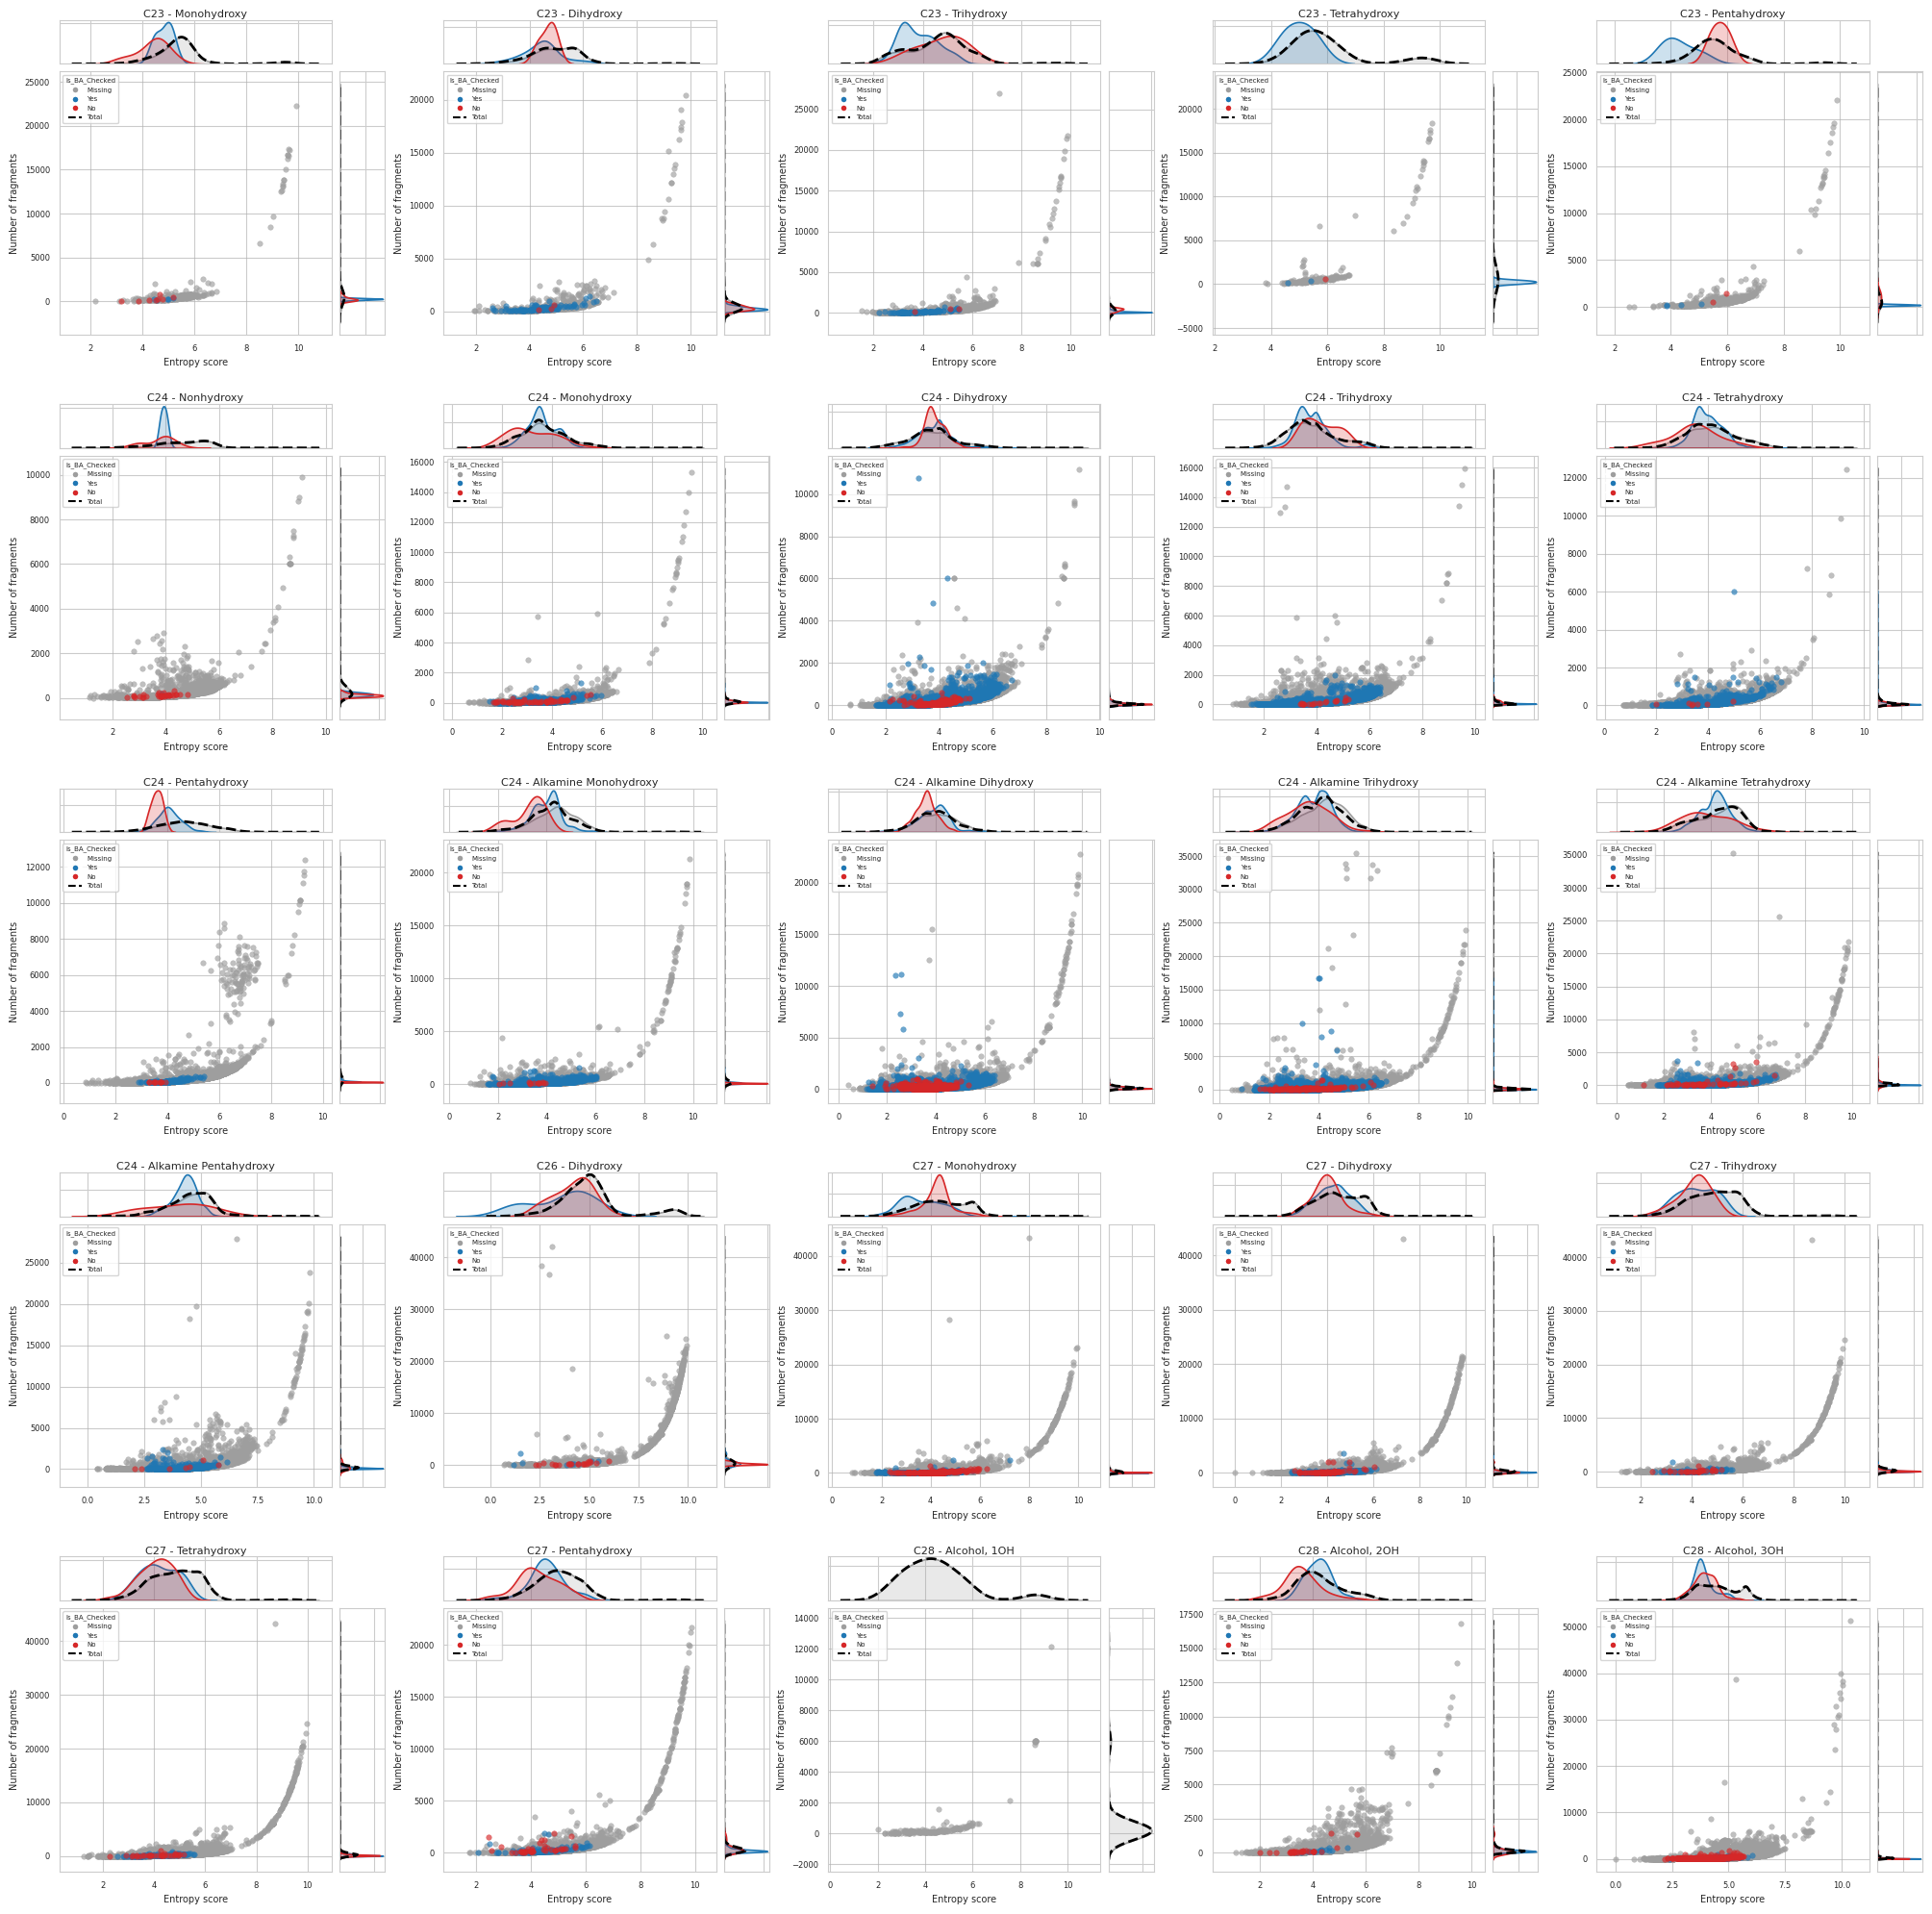

In [5]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

class_order = [
    "C23_monohydroxy",
    "C23_dihydroxy",
    "C23_trihydroxy",
    "C23_tetrahydroxy",
    "C23_pentahydroxy",
    "C24_nonhydroxy",
    "C24_monohydroxy",
    "C24_dihydroxy",
    "C24_trihydroxy_combined",
    "C24_tetrahydroxy",
    "C24_pentahydroxy",
    "C24_alkylamine_monohydroxy",
    "C24_alkylamine_dihydroxy",
    "C24_alkylamine_trihydroxy_combined",
    "C24_alkylamine_tetrahydroxy",
    "C24_alkylamine_pentahydroxy",
    "Aceto_dihydroxy",
    "C27_monohydroxy",
    "C27_dihydroxy",
    "C27_trihydroxy",
    "C27_tetrahydroxy",
    "C27_pentahydroxy",
    "C28_alcohol_1OH",
    "C28_alcohol_2OH",
    "C28_alcohol_3OH",
]

class_titles = {
    "C23_monohydroxy": "C23 - Monohydroxy",
    "C23_dihydroxy": "C23 - Dihydroxy",
    "C23_trihydroxy": "C23 - Trihydroxy",
    "C23_tetrahydroxy": "C23 - Tetrahydroxy",
    "C23_pentahydroxy": "C23 - Pentahydroxy",
    "C24_nonhydroxy": "C24 - Nonhydroxy",
    "C24_monohydroxy": "C24 - Monohydroxy",
    "C24_dihydroxy": "C24 - Dihydroxy",
    "C24_trihydroxy_combined": "C24 - Trihydroxy",
    "C24_tetrahydroxy": "C24 - Tetrahydroxy",
    "C24_pentahydroxy": "C24 - Pentahydroxy",
    "C24_alkylamine_monohydroxy": "C24 - Alkamine Monohydroxy",
    "C24_alkylamine_dihydroxy": "C24 - Alkamine Dihydroxy",
    "C24_alkylamine_trihydroxy_combined": "C24 - Alkamine Trihydroxy",
    "C24_alkylamine_tetrahydroxy": "C24 - Alkamine Tetrahydroxy",
    "C24_alkylamine_pentahydroxy": "C24 - Alkamine Pentahydroxy",
    "Aceto_dihydroxy": "C26 - Dihydroxy",
    "C27_monohydroxy": "C27 - Monohydroxy",
    "C27_dihydroxy": "C27 - Dihydroxy",
    "C27_trihydroxy": "C27 - Trihydroxy",
    "C27_tetrahydroxy": "C27 - Tetrahydroxy",
    "C27_pentahydroxy": "C27 - Pentahydroxy",
    "C28_alcohol_1OH": "C28 - Alcohol, 1OH",
    "C28_alcohol_2OH": "C28 - Alcohol, 2OH",
    "C28_alcohol_3OH": "C28 - Alcohol, 3OH",
}

fragments_df = pd.read_csv(
    f"{PROJECT_DIR}/Entropy/fragment_counts_per_scan_post_falcon.tsv",
    sep="\t",
)
ba_classification = pd.read_csv(
    f"{PROJECT_DIR}/postMN_final_filter/Classification_BAs_library_matches.tsv",
    sep="\t",
)

all_joint_parts = []

for ba_class in class_order:
    entropy_path = entropy_files.get(ba_class)
    task_id = library_matches_tasks.get(ba_class)

    if entropy_path is None:
        print(f"Skipping {ba_class}: missing entropy mapping.")
        continue

    if (not os.path.exists(entropy_path)) or os.path.getsize(entropy_path) == 0:
        print(f"Skipping {ba_class}: missing/empty entropy file -> {entropy_path}")
        continue

    try:
        df = pd.read_csv(entropy_path, sep="\t", low_memory=False)
    except Exception as e:
        print(f"Skipping {ba_class}: entropy read error -> {e}")
        continue

    if "scan_number" not in df.columns:
        print(f"Skipping {ba_class}: scan_number missing in entropy file.")
        continue

    # Default: no library matches, so all points become Missing (gray).
    library_matches = pd.DataFrame(columns=["scan_number", "SpectrumID", "Compound_Name"])

    if task_id is not None:
        library_path = f"{PROJECT_DIR}/library_results_postMN_filter/library_matches_files/{task_id}.tsv"
        if os.path.exists(library_path) and os.path.getsize(library_path) > 0:
            try:
                library_matches = pd.read_csv(library_path, sep="\t", low_memory=False)
            except Exception as e:
                print(f"{ba_class}: library read error -> {e}; plotting as Missing.")
        else:
            print(f"{ba_class}: library file missing/empty; plotting all points as Missing.")
    else:
        print(f"{ba_class}: library mapping missing; plotting all points as Missing.")

    if (not library_matches.empty) and ("#Scan#" in library_matches.columns):
        library_matches = library_matches.rename(columns={"#Scan#": "scan_number"})
    elif (not library_matches.empty) and ("scan_number" not in library_matches.columns):
        print(f"{ba_class}: no #Scan#/scan_number in library file; plotting as Missing.")
        library_matches = pd.DataFrame(columns=["scan_number", "SpectrumID", "Compound_Name"])

    class_fragments = fragments_df[
        fragments_df["BA_class"].astype("string").str.contains(ba_class, na=False)
    ]

    merged_df = pd.merge(
        df, class_fragments[["scan_number", "n_fragments"]], on="scan_number", how="left"
    )
    merged_df = pd.merge(
        merged_df, library_matches[["scan_number", "SpectrumID", "Compound_Name"]], on="scan_number", how="left"
    )
    merged_df = pd.merge(
        merged_df, ba_classification[["SpectrumID", "Is_BA_Checked"]], on="SpectrumID", how="left"
    )

    joint_df = merged_df[["entropy_score", "n_fragments", "Is_BA_Checked"]].copy()
    joint_df["entropy_score"] = pd.to_numeric(joint_df["entropy_score"], errors="coerce")
    joint_df["n_fragments"] = pd.to_numeric(joint_df["n_fragments"], errors="coerce")
    joint_df = joint_df.dropna(subset=["entropy_score", "n_fragments"])
    joint_df = joint_df[(joint_df["entropy_score"] >= 0) & (joint_df["n_fragments"] >= 0)]

    if joint_df.empty:
        print(f"Skipping {ba_class}: no valid points after filtering.")
        continue

    status = joint_df["Is_BA_Checked"].astype("string").str.strip().str.lower()
    joint_df["BA_status"] = status.map({"yes": "Yes", "no": "No"}).fillna("Missing")
    joint_df["BA_class"] = ba_class
    all_joint_parts.append(joint_df)

if not all_joint_parts:
    raise ValueError("No valid data available to plot.")

all_joint = pd.concat(all_joint_parts, ignore_index=True)
all_joint["BA_class"] = pd.Categorical(
    all_joint["BA_class"], categories=class_order, ordered=True
)
all_joint["BA_status"] = pd.Categorical(
    all_joint["BA_status"], categories=["Missing", "Yes", "No"], ordered=True
)

palette = {"Missing": "#9e9e9e", "Yes": "#1f77b4", "No": "#d62728", "Total": "#000000"}
order = ["Missing", "Yes", "No"]

sns.set_style("whitegrid")

# Build one vector-native 5x5 figure using nested grids (no raster capture).
n_rows, n_cols = 5, 5
fig = plt.figure(figsize=(n_cols * 5, n_rows * 5))
outer = fig.add_gridspec(n_rows, n_cols, wspace=0.18, hspace=0.22)

for i, ba_class in enumerate(class_order):
    if i >= n_rows * n_cols:
        break

    row, col = divmod(i, n_cols)
    sub = outer[row, col].subgridspec(
        2,
        2,
        height_ratios=[1, 6],
        width_ratios=[6, 1],
        hspace=0.05,
        wspace=0.05,
    )

    ax_top = fig.add_subplot(sub[0, 0])
    ax_main = fig.add_subplot(sub[1, 0], sharex=ax_top)
    ax_right = fig.add_subplot(sub[1, 1], sharey=ax_main)
    ax_corner = fig.add_subplot(sub[0, 1])
    ax_corner.axis("off")

    subset_class = all_joint[all_joint["BA_class"] == ba_class].copy()
    if subset_class.empty:
        ax_top.set_title(f"{class_titles.get(ba_class, ba_class)}: no valid data", fontsize=8, pad=2)
        ax_top.axis("off")
        ax_main.axis("off")
        ax_right.axis("off")
        continue

    # Main scatter: draw in layers so Missing stays behind Yes/No points.
    for idx, label in enumerate(order):
        grp = subset_class[subset_class["BA_status"] == label]
        if grp.empty:
            continue
        sns.scatterplot(
            data=grp,
            x="entropy_score",
            y="n_fragments",
            color=palette[label],
            s=16,
            alpha=0.65,
            edgecolor=None,
            ax=ax_main,
            legend=False,
            zorder=2 + idx,
        )

    ax_main.grid(True, which="major", color="#b0b0b0", alpha=0.65, linewidth=0.8)

    # Marginal densities by group with filled area.
    for label in order:
        grp = subset_class[subset_class["BA_status"] == label]
        if len(grp) > 1 and grp["entropy_score"].nunique() > 1:
            sns.kdeplot(
                data=grp,
                x="entropy_score",
                ax=ax_top,
                color=palette[label],
                fill=True,
                alpha=0.22,
                linewidth=1.2,
                common_norm=False,
            )
        if len(grp) > 1 and grp["n_fragments"].nunique() > 1:
            sns.kdeplot(
                data=grp,
                y="n_fragments",
                ax=ax_right,
                color=palette[label],
                fill=True,
                alpha=0.22,
                linewidth=1.2,
                common_norm=False,
            )

    # Total density (dashed black).
    if len(subset_class) > 1 and subset_class["entropy_score"].nunique() > 1:
        sns.kdeplot(
            data=subset_class,
            x="entropy_score",
            ax=ax_top,
            color=palette["Total"],
            linewidth=2.0,
            linestyle="--",
            fill=False,
            common_norm=False,
        )
    if len(subset_class) > 1 and subset_class["n_fragments"].nunique() > 1:
        sns.kdeplot(
            data=subset_class,
            y="n_fragments",
            ax=ax_right,
            color=palette["Total"],
            linewidth=2.0,
            linestyle="--",
            fill=False,
            common_norm=False,
        )

    ax_top.set_title(class_titles.get(ba_class, ba_class), fontsize=8, pad=2)
    ax_main.set_xlabel("Entropy score", fontsize=7)
    ax_main.set_ylabel("Number of fragments", fontsize=7)
    ax_main.tick_params(axis="both", labelsize=6)

    # Clean marginal axes to match JointGrid style.
    ax_top.set_xlabel("")
    ax_top.set_ylabel("")
    ax_top.tick_params(axis="x", labelbottom=False, bottom=False)
    ax_top.tick_params(axis="y", labelleft=False, left=False)

    ax_right.set_xlabel("")
    ax_right.set_ylabel("")
    ax_right.tick_params(axis="x", labelbottom=False, bottom=False)
    ax_right.tick_params(axis="y", labelleft=False, left=False)

    legend_handles = [
        Line2D([0], [0], marker="o", color="w", markerfacecolor=palette["Missing"], markersize=5, label="Missing"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor=palette["Yes"], markersize=5, label="Yes"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor=palette["No"], markersize=5, label="No"),
        Line2D([0], [0], color=palette["Total"], lw=1.5, linestyle="--", label="Total"),
    ]
    ax_main.legend(
        handles=legend_handles,
        title="Is_BA_Checked",
        loc="upper left",
        frameon=True,
        fontsize=5,
        title_fontsize=5,
    )

plt.tight_layout()
plt.savefig(
    # f"{PROJECT_DIR}/Entropy/Figures/entropy_all_900.pdf",
    format="pdf",
    dpi=900,
    bbox_inches="tight",
)
plt.show()